In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  
import seaborn as sns


In [17]:
df=pd.read_csv(r"F:\project\clean.csv")
df

,Brand,model,Year,kmDriven,Transmission,Owner,FuelType,Price
0,Maruti Suzuki,Wagon-R,2013,"80,000",Manual,first,Hybrid/CNG,"? 3,25,000."
1,Maruti Suzuki,Wagon-R,2021,"44,000",Automatic,first,Hybrid/CNG,"? 5,85,000."
2,Maruti Suzuki,Wagon-R,2014,"75,000",Manual,first,Hybrid/CNG,"? 1,95,000."
3,Maruti Suzuki,Wagon-R,2017,"96,000",Automatic,first,Hybrid/CNG,"? 3,50,000."
4,Maruti Suzuki,Wagon-R,2012,"58,000",Automatic,first,Hybrid/CNG,"? 2,45,000."
...,...,...,...,...,...,...,...,...
9577,Toyota,Innova Crysta,2021,37000.0,Automatic,first,Diesel,"? 32,50,000."
9578,Toyota,Innova Crysta,2021,"40,000",Automatic,first,Diesel,"? 26,50,000."
9579,Toyota,Innova Crysta,2016,"145,000",Automatic,first,Diesel,"? 18,20,000."
9580,Toyota,Innova Crysta,2016,"110,000",Automatic,second,Diesel,"? 15,45,000."


In [18]:
df.head()

,Brand,model,Year,kmDriven,Transmission,Owner,FuelType,Price
0,Maruti Suzuki,Wagon-R,2013,"80,000",Manual,first,Hybrid/CNG,"? 3,25,000."
1,Maruti Suzuki,Wagon-R,2021,"44,000",Automatic,first,Hybrid/CNG,"? 5,85,000."
2,Maruti Suzuki,Wagon-R,2014,"75,000",Manual,first,Hybrid/CNG,"? 1,95,000."
3,Maruti Suzuki,Wagon-R,2017,"96,000",Automatic,first,Hybrid/CNG,"? 3,50,000."
4,Maruti Suzuki,Wagon-R,2012,"58,000",Automatic,first,Hybrid/CNG,"? 2,45,000."


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9582 entries, 0 to 9581
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Brand         9582 non-null   object
 1   model         9582 non-null   object
 2   Year          9582 non-null   int64 
 3   kmDriven      9535 non-null   object
 4   Transmission  9582 non-null   object
 5   Owner         9582 non-null   object
 6   FuelType      9582 non-null   object
 7   Price         9582 non-null   object
dtypes: int64(1), object(7)
memory usage: 599.0+ KB


In [20]:
df.duplicated().sum()

np.int64(811)

In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df.isnull().sum()

Brand            0
model            0
Year             0
kmDriven        46
Transmission     0
Owner            0
FuelType         0
Price            0
dtype: int64

In [23]:
df.dtypes

Brand           object
model           object
Year             int64
kmDriven        object
Transmission    object
Owner           object
FuelType        object
Price           object
dtype: object

In [24]:
df['Price'] = df['Price'].str.replace('[^0-9.]', '', regex=True)
df['kmDriven'] = df['kmDriven'].str.replace('[^0-9.]', '', regex=True)
df['Price'] = pd.to_numeric(df['Price'])
df['kmDriven'] = pd.to_numeric(df['kmDriven'])

In [25]:
df.dtypes

Brand            object
model            object
Year              int64
kmDriven        float64
Transmission     object
Owner            object
FuelType         object
Price           float64
dtype: object

In [26]:
df['kmDriven']=df['kmDriven'].fillna(df['kmDriven'].mean())

In [27]:
df.isnull().sum()

Brand           0
model           0
Year            0
kmDriven        0
Transmission    0
Owner           0
FuelType        0
Price           0
dtype: int64

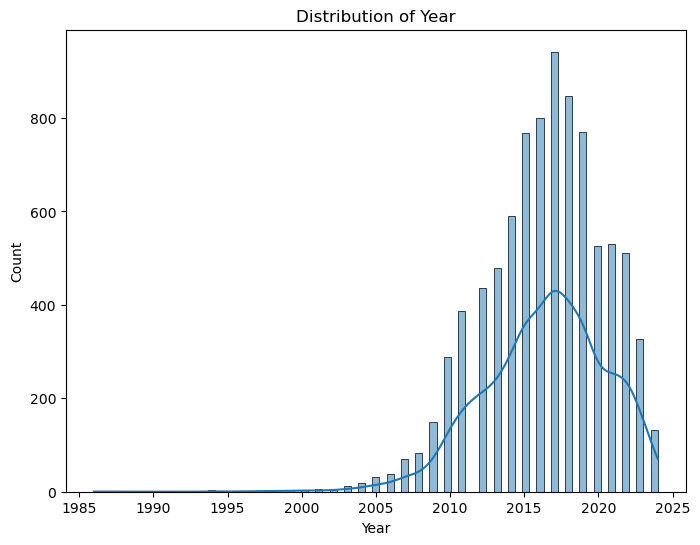

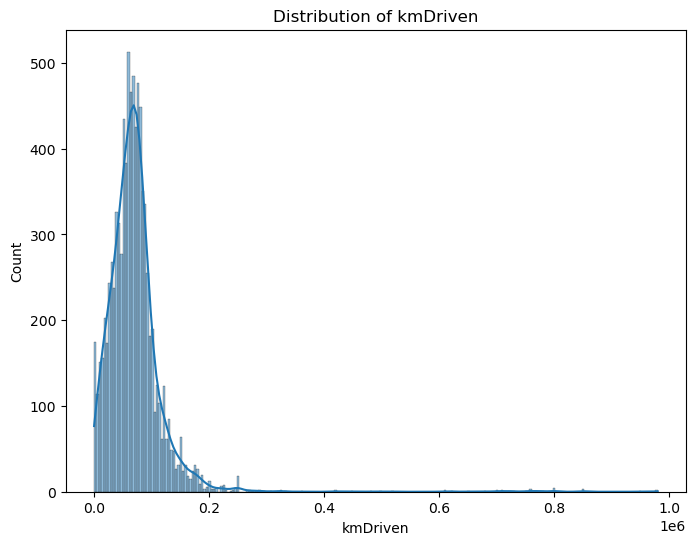

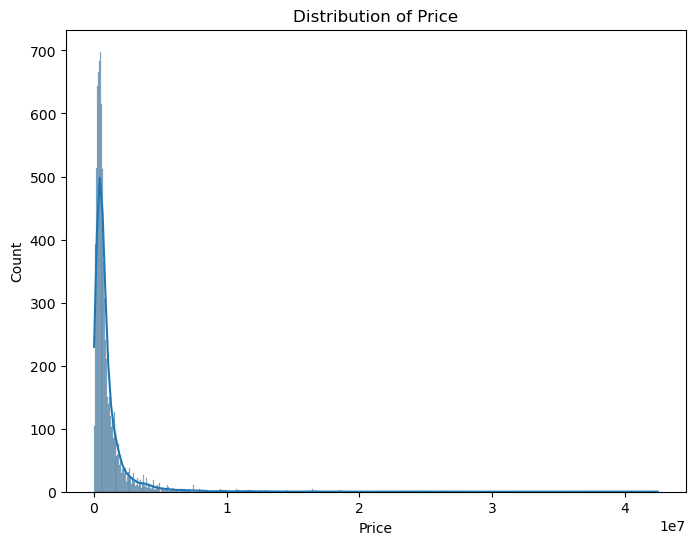

In [28]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    plt.figure(figsize=(8,6))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

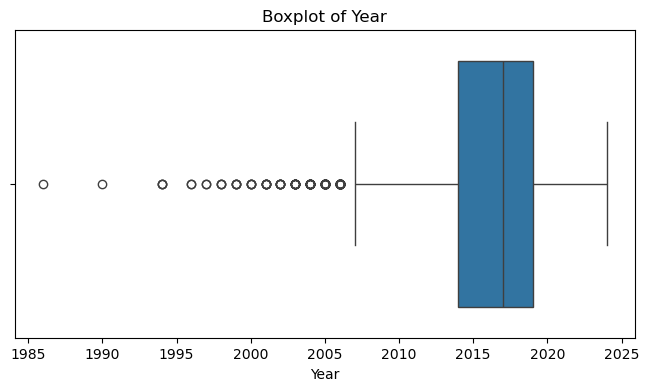

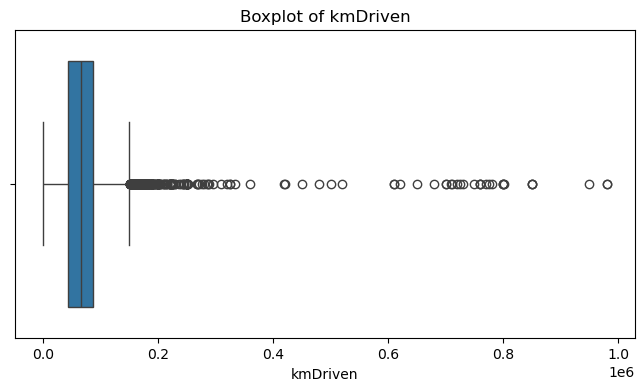

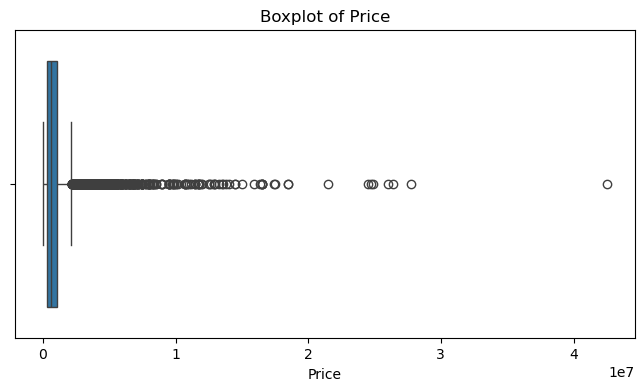

In [29]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [30]:
import numpy as np
df['Price'] = np.log1p(df['Price'])

In [31]:
lower = df['kmDriven'].quantile(0.01)
upper = df['kmDriven'].quantile(0.99)

df['kmDriven'] = df['kmDriven'].clip(lower, upper)
lower = df['Price'].quantile(0.01)
upper = df['Price'].quantile(0.99)

df['Price'] = df['Price'].clip(lower, upper)

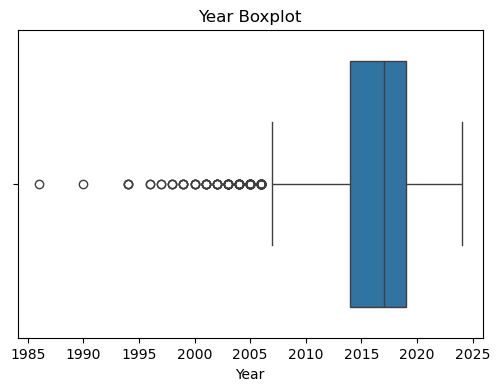

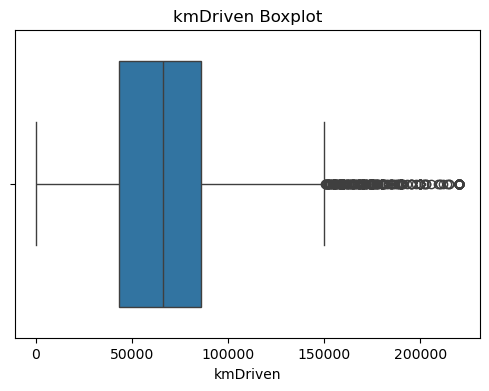

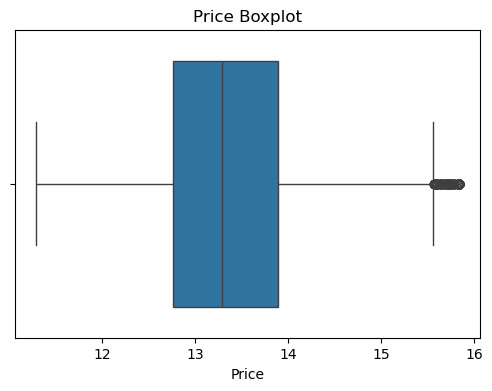

In [32]:
cols = ['Year','kmDriven','Price']
for col in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    plt.show()

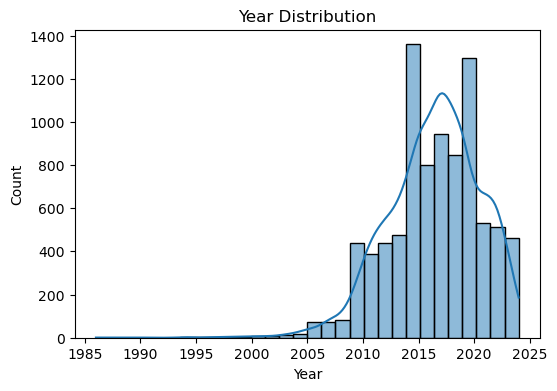

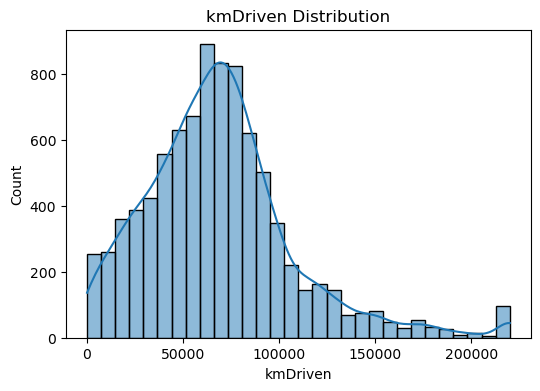

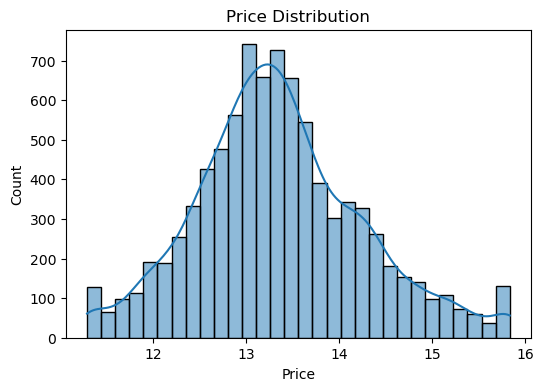

In [33]:
cols = ['Year','kmDriven','Price']

for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

In [34]:
df.columns

Index(['Brand', 'model', 'Year', 'kmDriven', 'Transmission', 'Owner',
       'FuelType', 'Price'],
      dtype='object')

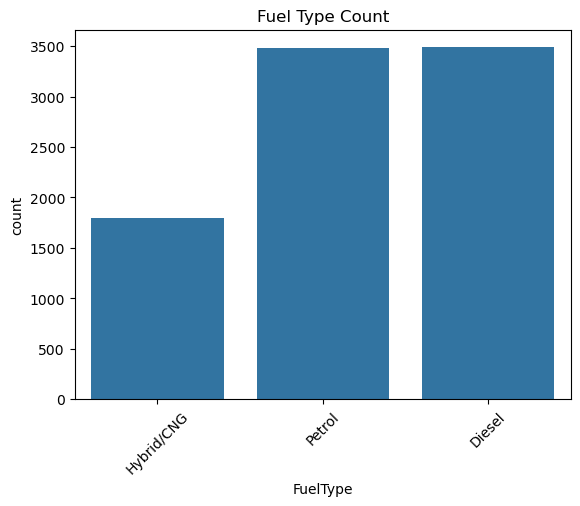

In [35]:
sns.countplot(x=df['FuelType'])
plt.title("Fuel Type Count")
plt.xticks(rotation=45)
plt.show()

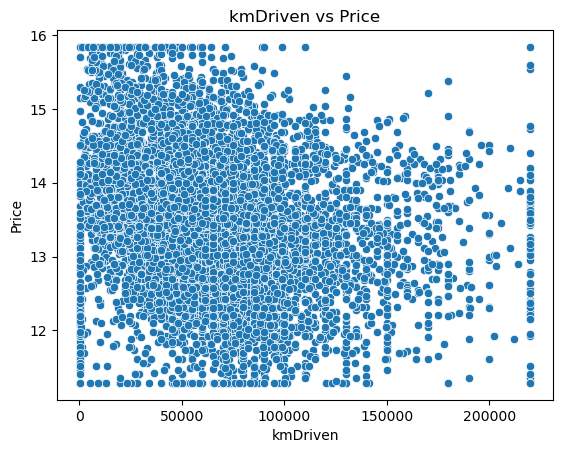

In [36]:
sns.scatterplot(x=df['kmDriven'], y=df['Price'])
plt.title("kmDriven vs Price")
plt.show()

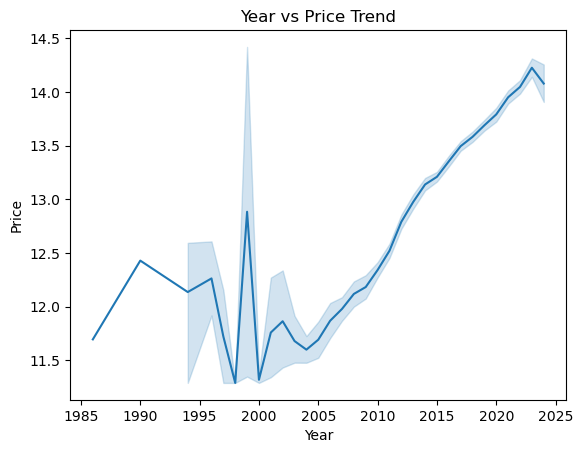

In [37]:
sns.lineplot(x=df['Year'], y=df['Price'])
plt.title("Year vs Price Trend")
plt.show()

C:\Users\A.Arun Sundar\AppData\Local\Temp\ipykernel_26648\1073209253.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_price.index, y=brand_price.values, palette='viridis')


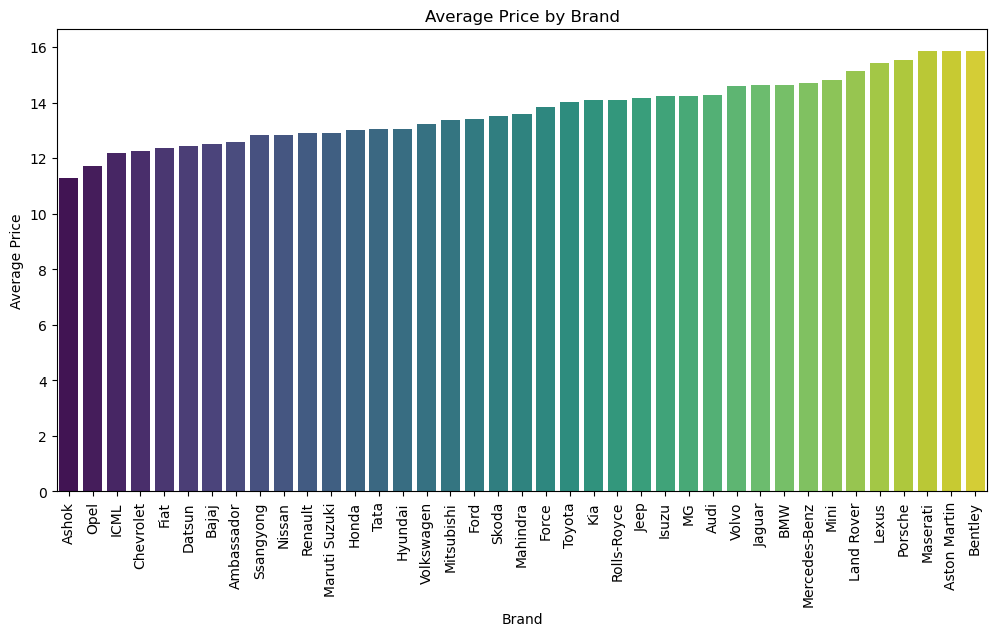

In [38]:
plt.figure(figsize=(12,6))

brand_price = df.groupby('Brand')['Price'].mean().sort_values()
sns.barplot(x=brand_price.index, y=brand_price.values, palette='viridis')
plt.xticks(rotation=90)
plt.title("Average Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price")
plt.show()

C:\Users\A.Arun Sundar\AppData\Local\Temp\ipykernel_26648\1891694893.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=owner_price.index, y=owner_price.values, palette=colors)


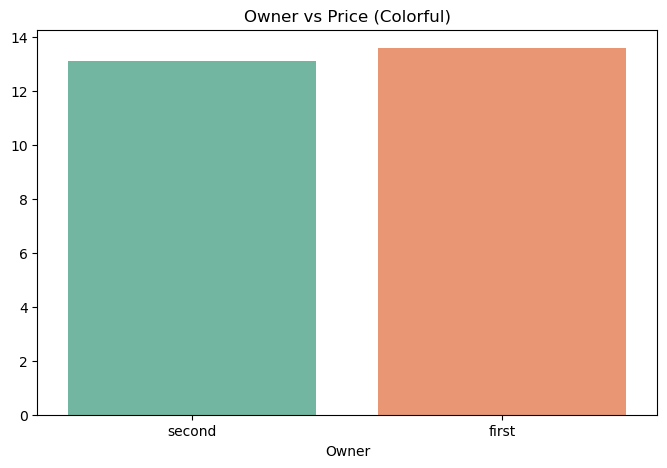

In [39]:
plt.figure(figsize=(8,5))
owner_price = df.groupby('Owner')['Price'].mean().sort_values()
colors = sns.color_palette("Set2", len(owner_price))
sns.barplot(x=owner_price.index, y=owner_price.values, palette=colors)
plt.title("Owner vs Price (Colorful)")
plt.show()

C:\Users\A.Arun Sundar\AppData\Local\Temp\ipykernel_26648\2068088206.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=trans_price.index, y=trans_price.values, palette='viridis')


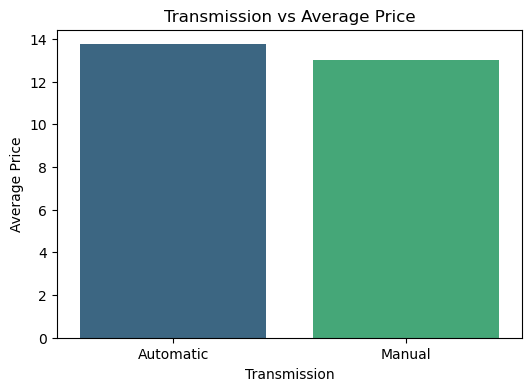

In [40]:
plt.figure(figsize=(6,4))
trans_price = df.groupby('Transmission')['Price'].mean()
sns.barplot(x=trans_price.index, y=trans_price.values, palette='viridis')
plt.title("Transmission vs Average Price")
plt.xlabel("Transmission")
plt.ylabel("Average Price")
plt.show()

C:\Users\A.Arun Sundar\AppData\Local\Temp\ipykernel_26648\892350018.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fuel_price.index, y=fuel_price.values, palette='viridis')


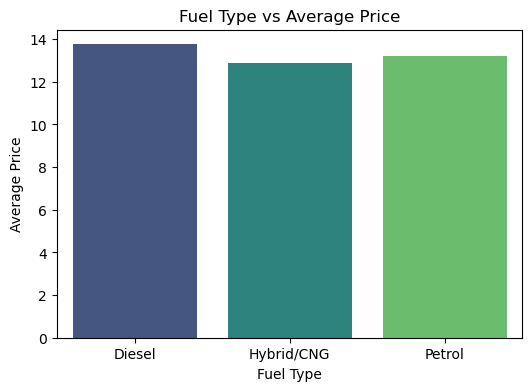

In [41]:
plt.figure(figsize=(6,4))
fuel_price = df.groupby('FuelType')['Price'].mean()
sns.barplot(x=fuel_price.index, y=fuel_price.values, palette='viridis')
plt.title("Fuel Type vs Average Price")
plt.xlabel("Fuel Type")
plt.ylabel("Average Price")

plt.show()

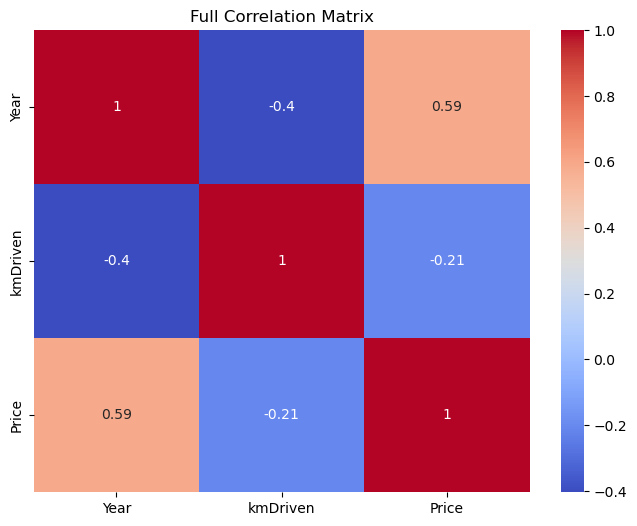

In [42]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), 
            annot=True, 
           cmap='coolwarm')

plt.title("Full Correlation Matrix")
plt.show()

In [43]:
df

,Brand,model,Year,kmDriven,Transmission,Owner,FuelType,Price
0,Maruti Suzuki,Wagon-R,2013,80000.0,Manual,first,Hybrid/CNG,12.691584
1,Maruti Suzuki,Wagon-R,2021,44000.0,Automatic,first,Hybrid/CNG,13.279369
2,Maruti Suzuki,Wagon-R,2014,75000.0,Manual,first,Hybrid/CNG,12.180760
3,Maruti Suzuki,Wagon-R,2017,96000.0,Automatic,first,Hybrid/CNG,12.765691
4,Maruti Suzuki,Wagon-R,2012,58000.0,Automatic,first,Hybrid/CNG,12.409018
...,...,...,...,...,...,...,...,...
9577,Toyota,Innova Crysta,2021,37000.0,Automatic,first,Diesel,14.994166
9578,Toyota,Innova Crysta,2021,40000.0,Automatic,first,Diesel,14.790071
9579,Toyota,Innova Crysta,2016,145000.0,Automatic,first,Diesel,14.414348
9580,Toyota,Innova Crysta,2016,110000.0,Automatic,second,Diesel,14.250535


In [44]:
df['FuelType'] = df['FuelType'].map({
    'Petrol': 0,
    'Diesel': 1,
    'CNG': 2
})

df['Transmission'] = df['Transmission'].map({
    'Manual': 0,
    'Automatic': 1
})

In [45]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
X = df.drop('Price', axis=1)
y = df['Price']

le = LabelEncoder()
X['Transmission'] = le.fit_transform(X['Transmission'])
X['Owner'] = le.fit_transform(X['Owner'])
X = pd.get_dummies(X, columns=['Brand', 'model', 'FuelType'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [46]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    'Linear': LinearRegression(),

    'Ridge': Ridge(alpha=1.0),

    'Lasso': Lasso(alpha=0.01),

    'RandomForest': RandomForestRegressor(
        n_estimators=500,
        max_depth=20,
        min_samples_split=3,
        min_samples_leaf=1,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print(f"--- {name} ---")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2  :", r2)
    print()

--- Linear ---
MAE : 0.19819057553619415
MSE : 0.08453947077498308
RMSE: 0.2907567209455064
R2  : 0.8941022777646737

--- Ridge ---
MAE : 0.1981863743209853
MSE : 0.08453767022102722
RMSE: 0.2907536246051409
R2  : 0.8941045332148313

--- Lasso ---
MAE : 0.22094580711122025
MSE : 0.09678050140253872
RMSE: 0.3110956467110054
R2  : 0.8787686442632133

--- RandomForest ---
MAE : 0.30156469452550166
MSE : 0.1665677970317847
RMSE: 0.4081271824220787
R2  : 0.7913501215264063



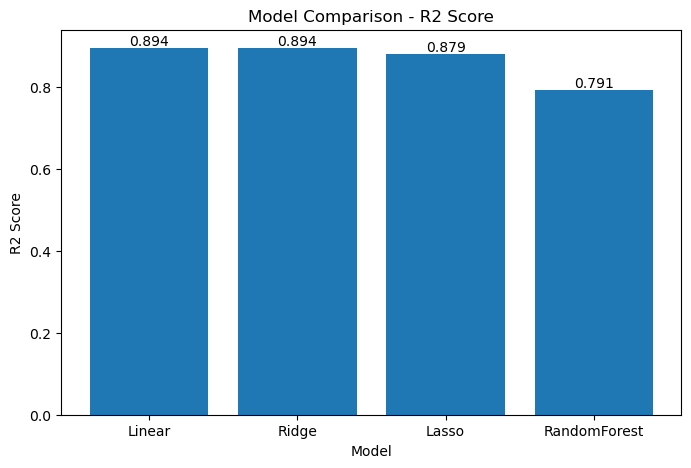

In [47]:

results = pd.DataFrame({
    'Model': ['Linear', 'Ridge', 'Lasso', 'RandomForest'],
    'MAE': [0.19819, 0.19818, 0.22094, 0.30156],
    'RMSE': [0.29075, 0.29075, 0.31109, 0.40812],
    'R2': [0.89410, 0.89410, 0.87876, 0.79135]
})
plt.figure(figsize=(8,5))
plt.bar(results['Model'], results['R2'])
plt.title("Model Comparison - R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
for i, v in enumerate(results['R2']):
    plt.text(i, v, f"{v:.3f}", ha='center', va='bottom')

plt.show()

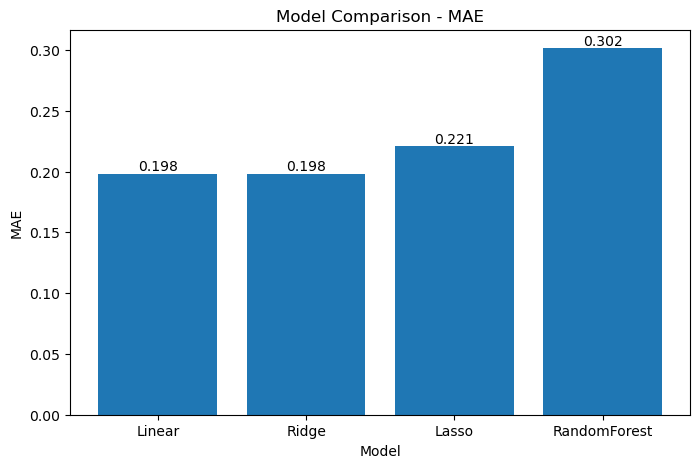

In [48]:
plt.figure(figsize=(8,5))
plt.bar(results['Model'], results['MAE'])
plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("MAE")

for i, v in enumerate(results['MAE']):
    plt.text(i, v, f"{v:.3f}", ha='center', va='bottom')

plt.show()

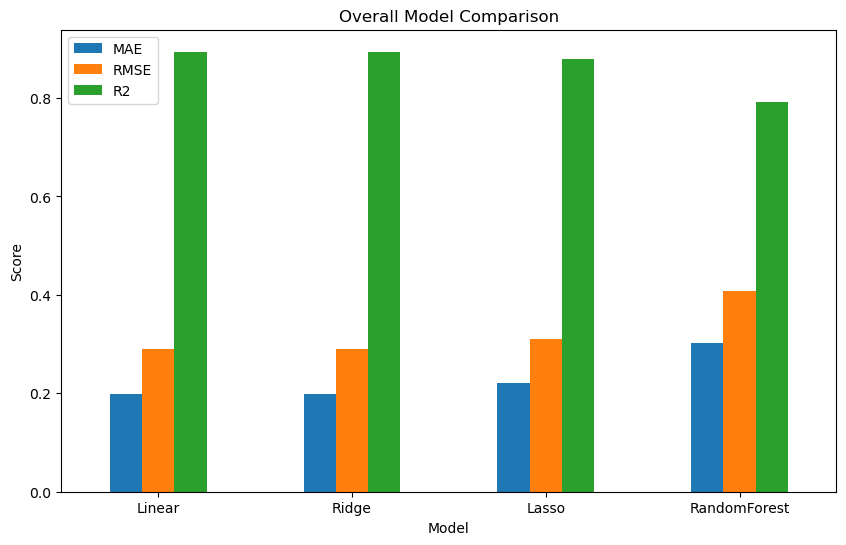

In [49]:
results.set_index('Model').plot(kind='bar', figsize=(10,6))

plt.title("Overall Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()